# Notebook 02 — Baseline HPPC One-SOC Smoke Test

## Goal

This notebook verifies that a PyBaMM-generated HPPC pulse can be used to extract ECM-level observables, including:

- short-window resistance Ri
- voltage relaxation structure
- biexponential relaxation time constants (tau1 / tau2)

The notebook establishes the first mechanism-to-observable extraction chain for the aging-bridge project.

Only a single baseline condition is tested in this notebook. No aging perturbation is applied.

## Scientific context

The aging-bridge project aims to connect DFN-level electrochemical perturbations with engineering-level observable signatures.

The present notebook tests whether standard ECM observables can be consistently extracted from DFN-generated pulse-relaxation behavior.

This forms the basis for later perturbation studies involving:
- diffusion limitation
- exchange-current degradation
- contact resistance growth
- lithium inventory loss
- active material loss

## Workflow

1. Build a baseline Chen2020 DFN model.
2. Initialize the cell near a selected SOC.
3. Apply a single HPPC-style pulse.
4. Record voltage and current response.
5. Extract:
   - instantaneous resistance behavior
   - relaxation voltage trajectory
   - biexponential relaxation fit
6. Visualize pulse and relaxation behavior.

## Expected outputs

- baseline HPPC pulse-response dataframe
- pulse + relaxation plots
- Ri estimate
- biexponential fit result
- tau1 / tau2 extraction

## Interpretation boundary

This notebook does not evaluate aging mechanisms.

A successful result only demonstrates that:
- PyBaMM pulse-relaxation behavior is extractable
- relaxation fitting is numerically stable
- ECM-level observables can be derived from DFN simulations

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [3]:
model = pybamm.lithium_ion.DFN()
param = pybamm.ParameterValues("Chen2020")

SOC_INIT = 0.50

experiment = pybamm.Experiment(
    [
        "Rest for 60 seconds",
        "Discharge at 1C for 10 seconds",
        "Rest for 600 seconds",
    ],
    period="0.1 seconds",
)

sim = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=experiment,
)

# PyBaMM 26.x requires a direction argument.
# For an HPPC discharge pulse, use direction="discharge".
sim.set_initial_soc(SOC_INIT, direction="discharge")

print("Model:", type(model).__name__)
print("Parameter set: Chen2020")
print("Initial SOC:", SOC_INIT)
print("Initial SOC direction: discharge")
print("Experiment steps:")
for i, step in enumerate(experiment.steps):
    print(f"{i+1}.", step)

Model: DFN
Parameter set: Chen2020
Initial SOC: 0.5
Initial SOC direction: discharge
Experiment steps:
1. Rest for 60 seconds
2. Discharge at 1C for 10 seconds
3. Rest for 600 seconds


In [4]:
solution = sim.solve()

print("[OK] HPPC one-SOC simulation solved")
print("Termination:", solution.termination)

[OK] HPPC one-SOC simulation solved
Termination: final time


In [5]:
df = pd.DataFrame(
    {
        "time_s": solution["Time [s]"].entries,
        "voltage_V": solution["Terminal voltage [V]"].entries,
        "current_A_pybamm": solution["Current [A]"].entries,
    }
)

df["time_rel_s"] = df["time_s"] - df["time_s"].iloc[0]
df["current_A_exp"] = -df["current_A_pybamm"]

out_csv = DATA / "baseline_chen2020_hppc_soc50_one_pulse.csv"
df.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
print("Rows:", len(df))
display(df.head())
display(df.tail())
display(df.describe())

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/baseline_chen2020_hppc_soc50_one_pulse.csv
Rows: 6703


,time_s,voltage_V,current_A_pybamm,time_rel_s,current_A_exp
0,0.0,3.750874,0.0,0.0,-0.0
1,0.1,3.750874,0.0,0.1,-0.0
2,0.2,3.750874,0.0,0.2,-0.0
3,0.3,3.750874,0.0,0.3,-0.0
4,0.4,3.750874,0.0,0.4,-0.0


,time_s,voltage_V,current_A_pybamm,time_rel_s,current_A_exp
6698,669.6,3.747973,0.0,669.6,-0.0
6699,669.7,3.747974,0.0,669.7,-0.0
6700,669.8,3.747974,0.0,669.8,-0.0
6701,669.9,3.747974,0.0,669.9,-0.0
6702,670.0,3.747974,0.0,670.0,-0.0


,time_s,voltage_V,current_A_pybamm,time_rel_s,current_A_exp
count,6703.000000,6703.000000,6703.000000,6703.000000,6703.000000
mean,334.919439,3.744744,0.075339,334.919439,-0.075339
std,193.483003,0.015917,0.609160,193.483003,0.609160
min,0.000000,3.607325,0.000000,0.000000,-5.000000
25%,167.350000,3.746571,0.000000,167.350000,-0.000000
50%,334.900000,3.747507,0.000000,334.900000,0.000000
75%,502.450000,3.747849,0.000000,502.450000,-0.000000
max,670.000000,3.750874,5.000000,670.000000,-0.000000


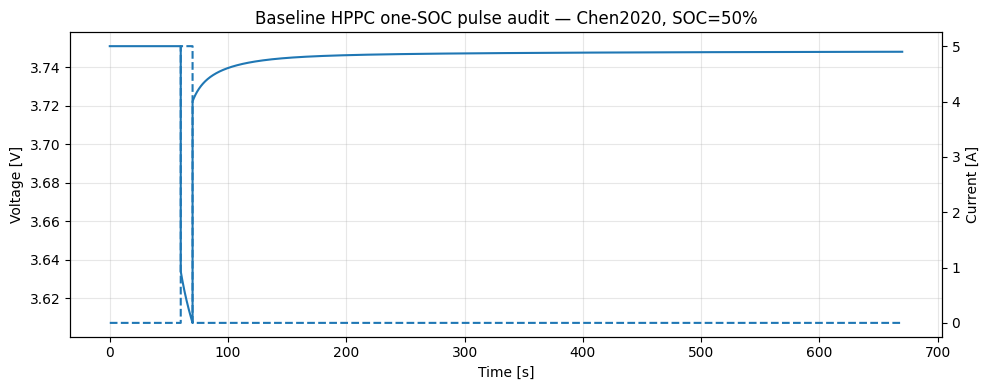

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/baseline_chen2020_hppc_soc50_voltage_current.png


In [6]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(df["time_rel_s"], df["voltage_V"], label="Terminal voltage [V]")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Voltage [V]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df["time_rel_s"], df["current_A_pybamm"], linestyle="--", label="Current [A], PyBaMM convention")
ax2.set_ylabel("Current [A]")

plt.title("Baseline HPPC one-SOC pulse audit — Chen2020, SOC=50%")
fig.tight_layout()

fig_path = FIGURES / "baseline_chen2020_hppc_soc50_voltage_current.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [7]:
current_abs = np.abs(df["current_A_pybamm"].values)

threshold_A = 0.1

pulse_mask = current_abs > threshold_A

pulse_indices = np.where(pulse_mask)[0]

pulse_start_idx = pulse_indices[0]
pulse_end_idx = pulse_indices[-1]

t_start = df.iloc[pulse_start_idx]["time_rel_s"]
t_end = df.iloc[pulse_end_idx]["time_rel_s"]

print("Pulse start index:", pulse_start_idx)
print("Pulse end index:", pulse_end_idx)

print("Pulse start time [s]:", t_start)
print("Pulse end time [s]:", t_end)

print("Pulse duration [s]:", t_end - t_start)

Pulse start index: 601
Pulse end index: 701
Pulse start time [s]: 60.00000000000001
Pulse end time [s]: 70.0
Pulse duration [s]: 9.999999999999993


In [11]:
# Corrected fixed-window Ri extraction around pulse start
# Sampling period is 0.1 s, so post window must include actual sampled points.

t = df["time_rel_s"].values
u = df["voltage_V"].values
i = df["current_A_pybamm"].values

pre_window_s = 1.0

post_delay_s = 0.1
post_window_s = 0.2

pre_mask = (t >= t_start - pre_window_s) & (t < t_start)
post_mask = (t >= t_start + post_delay_s) & (t <= t_start + post_delay_s + post_window_s)

print("pre points:", pre_mask.sum())
print("post points:", post_mask.sum())

U_before = np.median(u[pre_mask])
I_before = np.median(i[pre_mask])

U_after = np.median(u[post_mask])
I_after = np.median(i[post_mask])

dU = U_after - U_before
dI = I_after - I_before

Ri_ohm = abs(dU / dI)
Ri_mohm = Ri_ohm * 1000

ri_result = {
    "t_start_s": float(t_start),
    "U_before_V": float(U_before),
    "U_after_V": float(U_after),
    "dU_V": float(dU),
    "I_before_A_pybamm": float(I_before),
    "I_after_A_pybamm": float(I_after),
    "dI_A_pybamm": float(dI),
    "Ri_ohm": float(Ri_ohm),
    "Ri_mohm": float(Ri_mohm),
    "pre_points": int(pre_mask.sum()),
    "post_points": int(post_mask.sum()),
    "pre_window_s": pre_window_s,
    "post_delay_s": post_delay_s,
    "post_window_s": post_window_s,
}

ri_result

pre points: 10
post points: 2


{'t_start_s': 60.00000000000001,
 'U_before_V': 3.7508736084464056,
 'U_after_V': 3.6331461781581327,
 'dU_V': -0.11772743028827293,
 'I_before_A_pybamm': 0.0,
 'I_after_A_pybamm': 5.0,
 'dI_A_pybamm': 5.0,
 'Ri_ohm': 0.023545486057654587,
 'Ri_mohm': 23.545486057654585,
 'pre_points': 10,
 'post_points': 2,
 'pre_window_s': 1.0,
 'post_delay_s': 0.1,
 'post_window_s': 0.2}

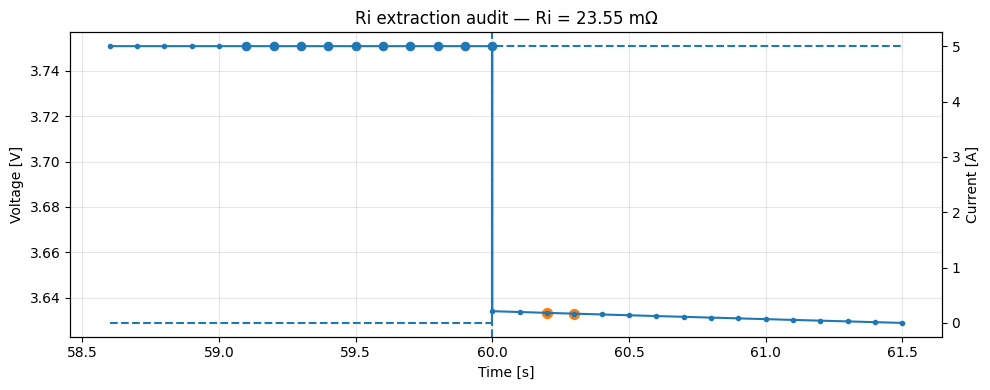

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/baseline_chen2020_hppc_soc50_Ri_window_audit_corrected.png
Ri = 23.545 mΩ


In [12]:
plot_mask = (df["time_rel_s"] >= t_start - 1.5) & (df["time_rel_s"] <= t_start + 1.5)

fig, ax1 = plt.subplots(figsize=(10, 4))

# voltage curve
ax1.plot(
    df.loc[plot_mask, "time_rel_s"],
    df.loc[plot_mask, "voltage_V"],
    marker="o",
    markersize=3,
    label="Voltage [V]",
)

# extraction points
ax1.scatter(
    df.loc[pre_mask, "time_rel_s"],
    df.loc[pre_mask, "voltage_V"],
    s=35,
    label="pre-window samples",
)

ax1.scatter(
    df.loc[post_mask, "time_rel_s"],
    df.loc[post_mask, "voltage_V"],
    s=50,
    label="post-window samples",
)

ax1.axvline(t_start, linestyle="--", label="pulse start")

ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Voltage [V]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.step(
    df.loc[plot_mask, "time_rel_s"],
    df.loc[plot_mask, "current_A_pybamm"],
    where="post",
    linestyle="--",
    label="Current [A], PyBaMM",
)
ax2.set_ylabel("Current [A]")

plt.title(f"Ri extraction audit — Ri = {Ri_mohm:.2f} mΩ")

fig.tight_layout()
fig_path = FIGURES / "baseline_chen2020_hppc_soc50_Ri_window_audit_corrected.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)
print(f"Ri = {Ri_mohm:.3f} mΩ")

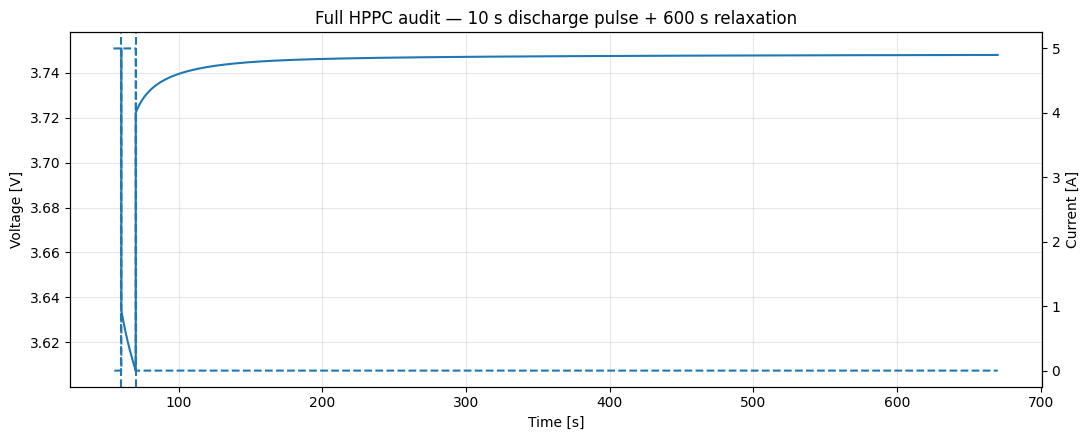

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/baseline_chen2020_hppc_soc50_full_relaxation_audit.png


In [13]:
plot_mask = (df["time_rel_s"] >= t_start - 5) & (df["time_rel_s"] <= t_end + 600)

fig, ax1 = plt.subplots(figsize=(11, 4.5))

ax1.plot(
    df.loc[plot_mask, "time_rel_s"],
    df.loc[plot_mask, "voltage_V"],
    label="Terminal voltage [V]",
)

ax1.axvline(t_start, linestyle="--", label="pulse start")
ax1.axvline(t_end, linestyle="--", label="pulse end")

ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Voltage [V]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.step(
    df.loc[plot_mask, "time_rel_s"],
    df.loc[plot_mask, "current_A_pybamm"],
    where="post",
    linestyle="--",
    label="Current [A], PyBaMM",
)
ax2.set_ylabel("Current [A]")

plt.title("Full HPPC audit — 10 s discharge pulse + 600 s relaxation")

fig.tight_layout()
fig_path = FIGURES / "baseline_chen2020_hppc_soc50_full_relaxation_audit.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [17]:
# Relaxation segment AFTER pulse removal
# Exclude last pulse point

relax_mask = (df["time_rel_s"] > t_end) & (df["time_rel_s"] <= t_end + 600)

relax = df.loc[relax_mask].copy()

relax["t_relax_s"] = relax["time_rel_s"] - t_end

print("Relaxation start [s]:", t_end)
print("Relaxation end [s]:", t_end + 600)
print("Relaxation points:", len(relax))

display(relax.head())
display(relax.tail())

Relaxation start [s]: 70.0
Relaxation end [s]: 670.0
Relaxation points: 6001


,time_s,voltage_V,current_A_pybamm,time_rel_s,current_A_exp,t_relax_s
702,70.0,3.722231,0.0,70.0,-0.0,1.421085e-14
703,70.1,3.722398,0.0,70.1,-0.0,1.000000e-01
704,70.2,3.722560,0.0,70.2,-0.0,2.000000e-01
705,70.3,3.722720,0.0,70.3,-0.0,3.000000e-01
706,70.4,3.722877,0.0,70.4,-0.0,4.000000e-01


,time_s,voltage_V,current_A_pybamm,time_rel_s,current_A_exp,t_relax_s
6698,669.6,3.747973,0.0,669.6,-0.0,599.6
6699,669.7,3.747974,0.0,669.7,-0.0,599.7
6700,669.8,3.747974,0.0,669.8,-0.0,599.8
6701,669.9,3.747974,0.0,669.9,-0.0,599.9
6702,670.0,3.747974,0.0,670.0,-0.0,600.0


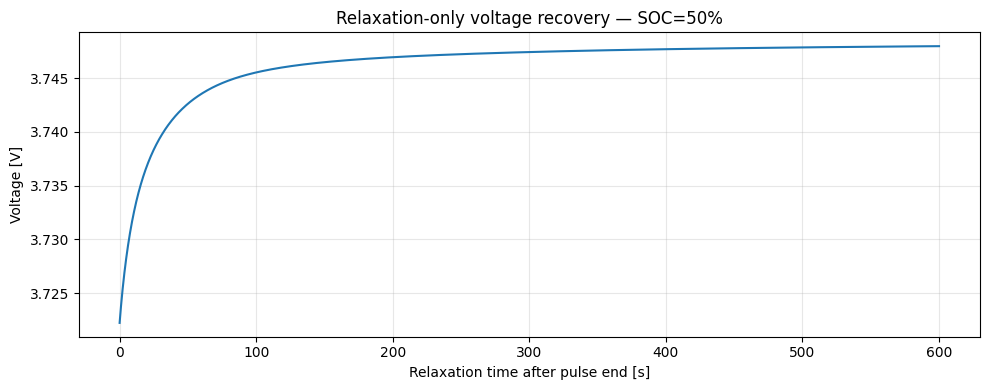

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/baseline_chen2020_hppc_soc50_relaxation_only.png


In [18]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    relax["t_relax_s"],
    relax["voltage_V"],
    label="Relaxation voltage",
)

ax.set_xlabel("Relaxation time after pulse end [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title("Relaxation-only voltage recovery — SOC=50%")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig_path = FIGURES / "baseline_chen2020_hppc_soc50_relaxation_only.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

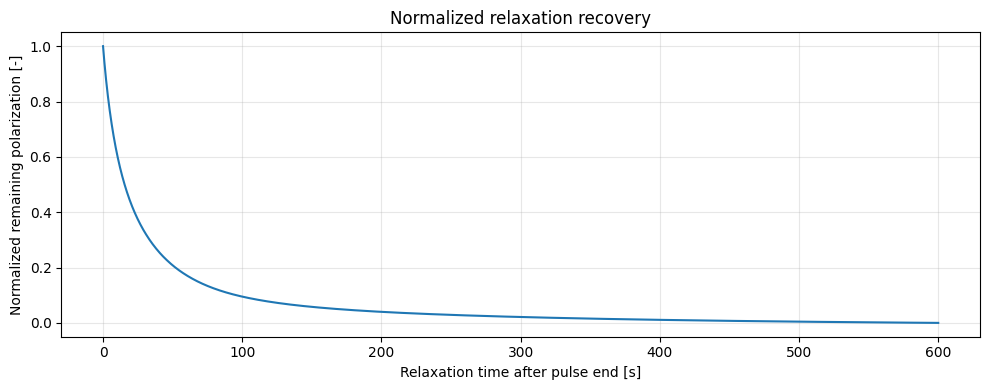

U0: 3.722231056133983
Uinf: 3.7479738237869626
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/baseline_chen2020_hppc_soc50_normalized_relaxation.png


In [19]:
U0 = relax["voltage_V"].iloc[0]
Uinf = relax["voltage_V"].iloc[-1]

remaining = (Uinf - relax["voltage_V"]) / (Uinf - U0)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(relax["t_relax_s"], remaining)
ax.set_xlabel("Relaxation time after pulse end [s]")
ax.set_ylabel("Normalized remaining polarization [-]")
ax.set_title("Normalized relaxation recovery")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig_path = FIGURES / "baseline_chen2020_hppc_soc50_normalized_relaxation.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("U0:", U0)
print("Uinf:", Uinf)
print("[OK] saved:", fig_path)

In [20]:
# CDEFG-style point extraction for one-pulse HPPC

# Windows
C_window = (t >= t_start - 1.0) & (t < t_start)
D_window = (t >= t_start + 0.1) & (t <= t_start + 0.3)
E_window = (t >= t_end - 0.3) & (t <= t_end)
F_window = (t > t_end) & (t <= t_end + 0.3)
G_window = (t >= t_end + 590) & (t <= t_end + 600)

points = {
    "C": {
        "t_s": float(np.median(t[C_window])),
        "U_V": float(np.median(u[C_window])),
        "meaning": "pre-pulse baseline",
    },
    "D": {
        "t_s": float(np.median(t[D_window])),
        "U_V": float(np.median(u[D_window])),
        "meaning": "short-time pulse response",
    },
    "E": {
        "t_s": float(np.median(t[E_window])),
        "U_V": float(np.median(u[E_window])),
        "meaning": "end-of-pulse voltage",
    },
    "F": {
        "t_s": float(np.median(t[F_window])),
        "U_V": float(np.median(u[F_window])),
        "meaning": "short-time recovery after current interruption",
    },
    "G": {
        "t_s": float(np.median(t[G_window])),
        "U_V": float(np.median(u[G_window])),
        "meaning": "long-time recovered voltage",
    },
}

points_df = pd.DataFrame(points).T
display(points_df)

Ri_CD_mohm = abs((points["D"]["U_V"] - points["C"]["U_V"]) / 5.0) * 1000
Ri_EF_mohm = abs((points["F"]["U_V"] - points["E"]["U_V"]) / 5.0) * 1000

print(f"Ri_CD = {Ri_CD_mohm:.3f} mΩ")
print(f"Ri_EF = {Ri_EF_mohm:.3f} mΩ")

,t_s,U_V,meaning
C,59.55,3.750874,pre-pulse baseline
D,60.25,3.633146,short-time pulse response
E,69.85,3.60763,end-of-pulse voltage
F,70.15,3.722479,short-time recovery after current interruption
G,665.0,3.747969,long-time recovered voltage


Ri_CD = 23.545 mΩ
Ri_EF = 22.970 mΩ


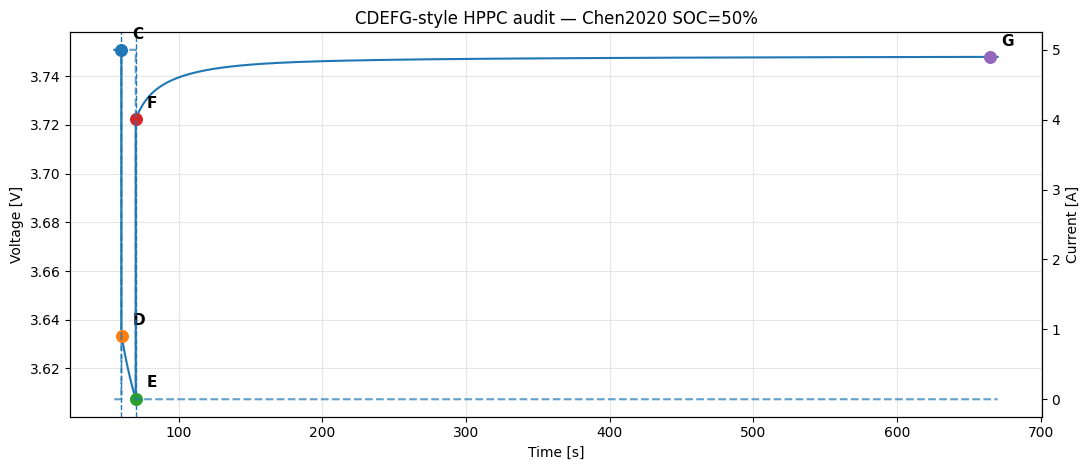

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/baseline_chen2020_hppc_soc50_CDEFG_audit.png


In [21]:
plot_mask = (df["time_rel_s"] >= t_start - 5) & (df["time_rel_s"] <= t_end + 600)

fig, ax1 = plt.subplots(figsize=(11, 4.8))

ax1.plot(
    df.loc[plot_mask, "time_rel_s"],
    df.loc[plot_mask, "voltage_V"],
    label="Terminal voltage [V]",
)

# Mark CDEFG points
for label, p in points.items():
    ax1.scatter(p["t_s"], p["U_V"], s=70, zorder=5)
    ax1.annotate(
        label,
        (p["t_s"], p["U_V"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=11,
        fontweight="bold",
    )

ax1.axvline(t_start, linestyle="--", linewidth=1)
ax1.axvline(t_end, linestyle="--", linewidth=1)

ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Voltage [V]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.step(
    df.loc[plot_mask, "time_rel_s"],
    df.loc[plot_mask, "current_A_pybamm"],
    where="post",
    linestyle="--",
    alpha=0.7,
    label="Current [A], PyBaMM",
)
ax2.set_ylabel("Current [A]")

plt.title("CDEFG-style HPPC audit — Chen2020 SOC=50%")

fig.tight_layout()
fig_path = FIGURES / "baseline_chen2020_hppc_soc50_CDEFG_audit.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

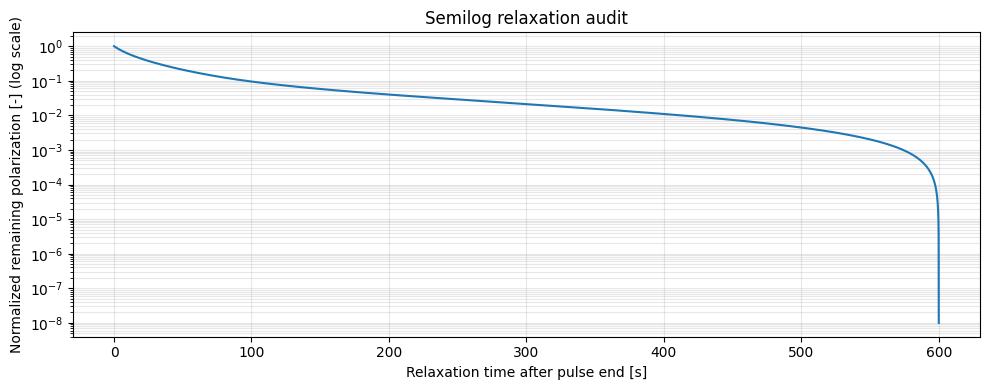

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/baseline_chen2020_hppc_soc50_semilog_relaxation.png


In [22]:
remaining = (Uinf - relax["voltage_V"]) / (Uinf - U0)

remaining = np.clip(remaining, 1e-8, None)

fig, ax = plt.subplots(figsize=(10, 4))

ax.semilogy(
    relax["t_relax_s"],
    remaining,
)

ax.set_xlabel("Relaxation time after pulse end [s]")
ax.set_ylabel("Normalized remaining polarization [-] (log scale)")
ax.set_title("Semilog relaxation audit")
ax.grid(True, which="both", alpha=0.3)

fig.tight_layout()
fig_path = FIGURES / "baseline_chen2020_hppc_soc50_semilog_relaxation.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [23]:
from scipy.optimize import curve_fit

# Use relaxation data after current interruption.
# Exclude very early transient and very late numerical floor.
fit_t_min = 0.5
fit_t_max = 300.0

fit_mask = (
    (relax["t_relax_s"] >= fit_t_min)
    & (relax["t_relax_s"] <= fit_t_max)
)

t_fit = relax.loc[fit_mask, "t_relax_s"].values
u_fit = relax.loc[fit_mask, "voltage_V"].values

# Use final 50 s median as Uinf estimate, not only last point.
tail_mask = relax["t_relax_s"] >= 550
Uinf_fit = float(np.median(relax.loc[tail_mask, "voltage_V"]))

def biexp(t, A1, tau1, A2, tau2):
    return Uinf_fit - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

# Initial guesses
A_total = Uinf_fit - u_fit[0]
p0 = [
    0.6 * A_total, 5.0,
    0.4 * A_total, 80.0,
]

bounds = (
    [0.0, 0.1, 0.0, 1.0],
    [1.0, 100.0, 1.0, 1000.0],
)

popt, pcov = curve_fit(
    biexp,
    t_fit,
    u_fit,
    p0=p0,
    bounds=bounds,
    maxfev=20000,
)

A1, tau1, A2, tau2 = popt

# Sort tau1 < tau2
if tau1 > tau2:
    A1, A2 = A2, A1
    tau1, tau2 = tau2, tau1

u_pred = biexp(t_fit, A1, tau1, A2, tau2)
residual = u_fit - u_pred

ss_res = np.sum(residual**2)
ss_tot = np.sum((u_fit - np.mean(u_fit))**2)
r2 = 1 - ss_res / ss_tot

rmse_mV = np.sqrt(np.mean(residual**2)) * 1000

fit_result = {
    "Uinf_fit_V": Uinf_fit,
    "A1_V": A1,
    "tau1_s": tau1,
    "A2_V": A2,
    "tau2_s": tau2,
    "R2": r2,
    "RMSE_mV": rmse_mV,
    "fit_t_min_s": fit_t_min,
    "fit_t_max_s": fit_t_max,
    "n_fit_points": len(t_fit),
}

fit_result

{'Uinf_fit_V': 3.7479490729196767,
 'A1_V': np.float64(0.0178996704842648),
 'tau1_s': np.float64(18.331256009910557),
 'A2_V': np.float64(0.0063048445614443185),
 'tau2_s': np.float64(107.08534470007133),
 'R2': np.float64(0.9987171713761213),
 'RMSE_mV': np.float64(0.15049381704452128),
 'fit_t_min_s': 0.5,
 'fit_t_max_s': 300.0,
 'n_fit_points': 2996}

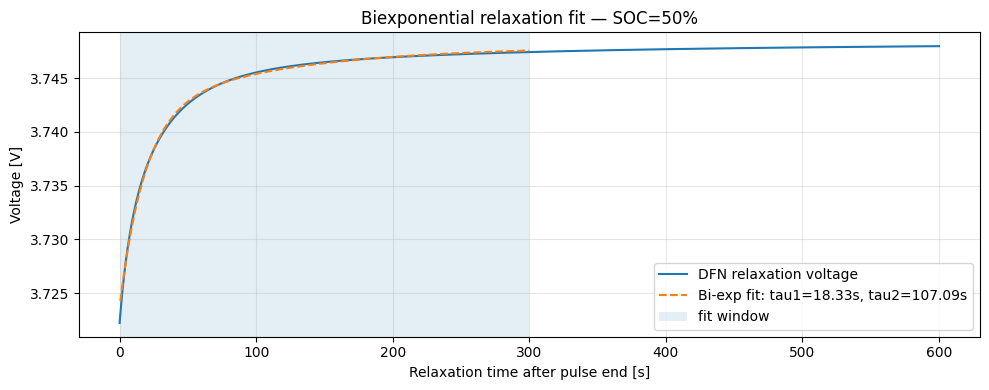

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/baseline_chen2020_hppc_soc50_biexp_fit.png
tau1 = 18.331 s
tau2 = 107.085 s
R2   = 0.998717
RMSE = 0.1505 mV


In [24]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    relax["t_relax_s"],
    relax["voltage_V"],
    label="DFN relaxation voltage",
)

ax.plot(
    t_fit,
    u_pred,
    linestyle="--",
    label=f"Bi-exp fit: tau1={tau1:.2f}s, tau2={tau2:.2f}s",
)

ax.axvspan(fit_t_min, fit_t_max, alpha=0.12, label="fit window")

ax.set_xlabel("Relaxation time after pulse end [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title("Biexponential relaxation fit — SOC=50%")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "baseline_chen2020_hppc_soc50_biexp_fit.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)
print(f"tau1 = {tau1:.3f} s")
print(f"tau2 = {tau2:.3f} s")
print(f"R2   = {r2:.6f}")
print(f"RMSE = {rmse_mV:.4f} mV")

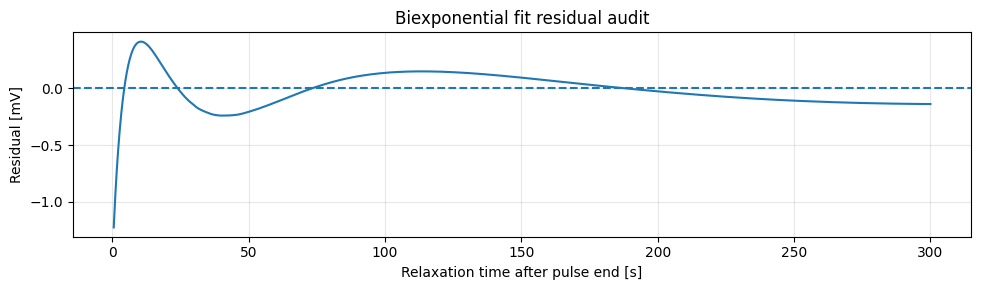

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/baseline_chen2020_hppc_soc50_biexp_residual.png
Residual max abs = 1.2245 mV


In [25]:
fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(t_fit, residual * 1000)
ax.axhline(0, linestyle="--")

ax.set_xlabel("Relaxation time after pulse end [s]")
ax.set_ylabel("Residual [mV]")
ax.set_title("Biexponential fit residual audit")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig_path = FIGURES / "baseline_chen2020_hppc_soc50_biexp_residual.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)
print(f"Residual max abs = {np.max(np.abs(residual))*1000:.4f} mV")

In [26]:
audit_summary = {
    "baseline_parameter_set": "Chen2020",
    "SOC_init": SOC_INIT,
    "pulse_current_A": 5.0,
    "pulse_duration_s": t_end - t_start,
    "Ri_CD_mohm": Ri_CD_mohm,
    "Ri_EF_mohm": Ri_EF_mohm,
    "tau1_s": tau1,
    "tau2_s": tau2,
    "biexp_R2": r2,
    "biexp_RMSE_mV": rmse_mV,
    "residual_max_abs_mV": np.max(np.abs(residual)) * 1000,
}

display(pd.DataFrame([audit_summary]))

,baseline_parameter_set,SOC_init,pulse_current_A,pulse_duration_s,Ri_CD_mohm,Ri_EF_mohm,tau1_s,tau2_s,biexp_R2,biexp_RMSE_mV,residual_max_abs_mV
0,Chen2020,0.5,5.0,10.0,23.545486,22.969868,18.331256,107.085345,0.998717,0.150494,1.224532


In [28]:
def fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0, tail_start_s=550):
    from scipy.optimize import curve_fit

    fit_mask = (
        (relax["t_relax_s"] >= fit_t_min)
        & (relax["t_relax_s"] <= fit_t_max)
    )

    t_fit_local = relax.loc[fit_mask, "t_relax_s"].values
    u_fit_local = relax.loc[fit_mask, "voltage_V"].values

    tail_mask = relax["t_relax_s"] >= tail_start_s
    Uinf_local = float(np.median(relax.loc[tail_mask, "voltage_V"]))

    def biexp_local(t, A1, tau1, A2, tau2):
        return Uinf_local - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

    A_total = Uinf_local - u_fit_local[0]

    p0 = [
        0.6 * A_total, 3.0,
        0.4 * A_total, 30.0,
    ]

    bounds = (
        [0.0, 0.1, 0.0, 1.0],
        [1.0, 100.0, 1.0, 1000.0],
    )

    popt, _ = curve_fit(
        biexp_local,
        t_fit_local,
        u_fit_local,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )

    A1, tau1, A2, tau2 = popt

    if tau1 > tau2:
        A1, A2 = A2, A1
        tau1, tau2 = tau2, tau1

    u_pred_local = biexp_local(t_fit_local, A1, tau1, A2, tau2)
    residual_local = u_fit_local - u_pred_local

    ss_res = np.sum(residual_local**2)
    ss_tot = np.sum((u_fit_local - np.mean(u_fit_local))**2)
    r2_local = 1 - ss_res / ss_tot
    rmse_mV_local = np.sqrt(np.mean(residual_local**2)) * 1000

    return {
        "fit_t_min_s": fit_t_min,
        "fit_t_max_s": fit_t_max,
        "Uinf_V": Uinf_local,
        "A1_V": A1,
        "tau1_s": tau1,
        "A2_V": A2,
        "tau2_s": tau2,
        "R2": r2_local,
        "RMSE_mV": rmse_mV_local,
        "n_fit_points": len(t_fit_local),
    }

fit_60 = fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0)
fit_300 = fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=300.0)

fit_compare = pd.DataFrame([fit_60, fit_300], index=["biexp_60s", "biexp_300s"])
display(fit_compare)

,fit_t_min_s,fit_t_max_s,Uinf_V,A1_V,tau1_s,A2_V,tau2_s,R2,RMSE_mV,n_fit_points
biexp_60s,0.5,60.0,3.747949,0.010694,9.440863,0.014748,48.698375,0.999945,0.038401,596
biexp_300s,0.5,300.0,3.747949,0.017900,18.331299,0.006305,107.085635,0.998717,0.150494,2996


In [29]:
print("""
Notebook conclusion:

The Chen2020 DFN baseline successfully produces:
- physically interpretable HPPC pulse-relaxation behavior
- extractable CDEFG structure
- stable fixed-window Ri estimates
- observable multi-timescale relaxation structure
- numerically stable biexponential fits

Key observation:
Extracted tau descriptors depend strongly on the fitting window.

This indicates that:
- tau1/tau2 should be treated as observation-window-dependent descriptors
- DFN relaxation behavior contains distributed time-scale structure
- biexponential fitting is an engineering approximation rather than a unique physical decomposition

This notebook establishes the first complete:
DFN → ECM observable extraction chain
for the aging-bridge project.
""")


Notebook conclusion:

The Chen2020 DFN baseline successfully produces:
- physically interpretable HPPC pulse-relaxation behavior
- extractable CDEFG structure
- stable fixed-window Ri estimates
- observable multi-timescale relaxation structure
- numerically stable biexponential fits

Key observation:
Extracted tau descriptors depend strongly on the fitting window.

This indicates that:
- tau1/tau2 should be treated as observation-window-dependent descriptors
- DFN relaxation behavior contains distributed time-scale structure
- biexponential fitting is an engineering approximation rather than a unique physical decomposition

This notebook establishes the first complete:
DFN → ECM observable extraction chain
for the aging-bridge project.

